# From Data to a Model You Can Defend

**Research to Production - Article 3**

The question we are still answering:

> **Can measurements taken from a breast tumour sample be used to distinguish a malignant tumour from a benign one?**

Article 2 ended with differences you can **see**: malignant nuclei are larger, their outlines are more
irregular, and two mediocre features plotted against each other almost separate the classes.

Seeing is not knowing. A picture cannot tell you whether a difference is real, whether a model has learned
biology or memorised 569 rows, or what happens to the patient the model gets wrong.

This notebook is the working session for article 3:

- **0.** Set up — two packages more than last time
- **1.** Load the data, and recompute what article 2 found
- **2.** Is the difference real? — t-tests, effect sizes, confidence intervals, multiple testing
- **3.** The first model — logistic regression, splitting, scaling, probabilities, coefficients
- **4.** Training strategies — cross-validation, hyperparameter tuning, regularisation, class weights
- **5.** Accuracy is not enough — precision, recall, ROC-AUC, PR-AUC, thresholds, confidence intervals
- **6.** When a good model is actually a bad model — overfitting and data leakage, demonstrated
- **7.** Do we really need all thirty features? — feature selection and PCA
- **8.** What I would put my name on — the result, stated properly

Every random seed is fixed, so the numbers below are the numbers in the article. Run the cells top to bottom.

---
## 0. Set up your environment

If you have already run the article 2 notebook you have an environment. It needs two more packages:

```bash
source .venv/bin/activate            # Windows PowerShell: .venv\Scripts\Activate.ps1
pip install scikit-learn scipy
```

| Package | What it does here |
| --- | --- |
| `scikit-learn` | splitting, pipelines, logistic regression, cross-validation, metrics, PCA |
| `scipy` | the t-tests and Mann-Whitney tests in section 2 |

If you are starting fresh, everything at once:

```bash
python3 -m venv .venv
source .venv/bin/activate
pip install --upgrade pip
pip install pandas matplotlib scikit-learn scipy jupyterlab ipykernel
python -m ipykernel install --user --name research-to-production
jupyter lab
```

Then **Kernel → Change Kernel → research-to-production**. The cell below is the check that saves you an
hour: it prints which Python is actually executing your code.

In [1]:
import sys
from importlib.metadata import version, PackageNotFoundError

print("python executable:", sys.executable)
print("python version:   ", sys.version.split()[0])
print("inside a venv:    ", sys.prefix != sys.base_prefix)
print()

for package in ["pandas", "numpy", "matplotlib", "scikit-learn", "scipy", "jupyterlab", "ipykernel"]:
    try:
        print(f"{package:<14} {version(package)}")
    except PackageNotFoundError:
        print(f"{package:<14} NOT INSTALLED  <-- pip install {package}")

python executable: /home/riccha/Documents/bench2growth/biological-question-to-data-science/.venv/bin/python
python version:    3.12.3
inside a venv:     True

pandas         3.0.5
numpy          2.5.2
matplotlib     3.11.1
scikit-learn   1.9.0
scipy          1.18.0
jupyterlab     4.6.2
ipykernel      7.3.0


`inside a venv` should say `True`, and `python executable` should contain `.venv`. If not, the kernel step
did not take effect and any `ModuleNotFoundError` below is about *which* Python is running, not about pip.

---
## 1. Getting the data in, and what article 2 found

Same load as last time: the file has no header, so we supply the column names in the order `wdbc.names`
documents. `id` goes to the index — it is a patient identifier, it carries no biological signal, and it must
never reach a model.

The `data/` folder is created by the article 2 notebook. If it is missing, run section 1 of
`exploratory_data_analysis.ipynb`, or fetch the two files directly:

```bash
mkdir -p data
BASE="https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin"
curl -fLo data/wdbc.data  "$BASE/wdbc.data"
curl -fLo data/wdbc.names "$BASE/wdbc.names"
```

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

Path("figures").mkdir(exist_ok=True)

# Blue is benign, orange is malignant, in every figure of this series. Fixed in article 2, never changed.
BENIGN, MALIGNANT = "#1f77b4", "#ff7f0e"
# Two more, for figures that are about the model rather than the biology:
# purple = the optimistic number (training performance), grey = the honest one (validated performance).
OPTIMISTIC, HONEST = "#7a5195", "#3f3f3f"

plt.rcParams.update({
    "figure.dpi": 150, "savefig.dpi": 150, "font.size": 9,
    "axes.spines.top": False, "axes.spines.right": False, "savefig.bbox": "tight",
})

measurements = [
    "radius", "texture", "perimeter", "area", "smoothness",
    "compactness", "concavity", "concave_points", "symmetry", "fractal_dimension",
]

columns = ["id", "diagnosis"] + [
    f"{m}_{summary}" for summary in ["mean", "se", "worst"] for m in measurements
]

df = pd.read_csv("data/wdbc.data", header=None, names=columns).set_index("id")

print(f"{df.shape[0]} samples, {df.shape[1] - 1} feature columns + 1 diagnosis column")
print(df["diagnosis"].value_counts().to_string())
print()
print(f"malignant prevalence: {(df.diagnosis == 'M').mean():.3f}")
print(f"baseline to beat (predict benign for everyone): {(df.diagnosis == 'B').mean():.3f}")

569 samples, 30 feature columns + 1 diagnosis column
diagnosis
B    357
M    212

malignant prevalence: 0.373
baseline to beat (predict benign for everyone): 0.627


That last number is the one to keep in mind all the way through. **62.7% accuracy requires no model at
all** — just the word "benign", repeated 569 times. Any result has to be read against that floor.

Now recompute article 2's findings, because everything below rests on them.

In [4]:
mean_features = [f"{m}_mean" for m in measurements]

# Finding 2: which measurements differ most between the classes?
by_class = df.groupby("diagnosis")[mean_features].mean().T
by_class["ratio_M_over_B"] = by_class["M"] / by_class["B"]
print("Article 2, finding 2 - malignant/benign ratio of the class means:")
print(by_class.sort_values("ratio_M_over_B", ascending=False).round(3).to_string())

Article 2, finding 2 - malignant/benign ratio of the class means:
diagnosis                     B        M  ratio_M_over_B
concavity_mean            0.046    0.161           3.491
concave_points_mean       0.026    0.088           3.421
area_mean               462.790  978.376           2.114
compactness_mean          0.080    0.145           1.813
perimeter_mean           78.075  115.365           1.478
radius_mean              12.147   17.463           1.438
texture_mean             17.915   21.605           1.206
smoothness_mean           0.092    0.103           1.113
symmetry_mean             0.174    0.193           1.107
fractal_dimension_mean    0.063    0.063           0.997


In [5]:
# Finding 4: the classes overlap, so no single threshold separates them.
for label, name in [("B", "benign   "), ("M", "malignant")]:
    values = df.loc[df.diagnosis == label, "radius_mean"]
    print(f"{name} radius_mean: {values.min():.2f} to {values.max():.2f}")

# Finding 5: the columns differ in scale by four orders of magnitude.
scales = df[mean_features].max()
print(f"\nlargest column max:  area_mean = {scales['area_mean']:.1f}")
print(f"smallest column max: fractal_dimension_mean = {scales['fractal_dimension_mean']:.3f}")
print(f"ratio: {scales['area_mean'] / scales['fractal_dimension_mean']:,.0f}x")

# Finding 6: thirty columns are not thirty independent facts.
print("\ncorrelations within the size cluster:")
print(df[["radius_mean", "perimeter_mean", "area_mean"]].corr().round(3).to_string())

benign    radius_mean: 6.98 to 17.85
malignant radius_mean: 10.95 to 28.11

largest column max:  area_mean = 2501.0
smallest column max: fractal_dimension_mean = 0.097
ratio: 25,667x

correlations within the size cluster:
                radius_mean  perimeter_mean  area_mean
radius_mean           1.000           0.998      0.987
perimeter_mean        0.998           1.000      0.987
area_mean             0.987           0.987      1.000


### The six findings we carry forward

1. **569 samples, 30 features, no missing values.** 357 benign, 212 malignant — 37.3% malignant, so the
   do-nothing baseline is **62.7%**.
2. **Shape beats size.** Concavity 3.5x, concave points 3.4x, area 2.1x, radius 1.4x. Outline irregularity
   separates the classes more sharply than size — which is what a cytologist would tell you.
3. **Fractal dimension is a genuine null.** Ratio 1.00. It is in the file and carries almost no signal.
4. **The classes overlap.** Benign radius 6.98–17.85, malignant 10.95–28.11. **No threshold on nuclear size
   separates them.**
5. **The scales differ by ~25,000x.** Anything that measures distance between samples will be dominated by
   `area` and will barely notice `fractal_dimension`.
6. **Thirty columns are not thirty facts.** `radius`, `perimeter` and `area` correlate above **0.99**.

Findings 4 and 6 are the ones that decide what happens next. Finding 4 is why one variable is not enough —
which is the honest reason this becomes a machine learning problem. Finding 6 is why section 9 exists.

---

## A model is an experiment. Where are its controls?

You would never run an assay without controls. You run a blank to see what the plate reads with nothing
in it. You run a negative control to see what happens when the thing you are testing is absent. You do
replicates, because one well is not a result.

Now think about how machine learning results are usually reported. "My model is 96% accurate." One number,
from one run, with nothing to compare it against. That is a single well with no blank, no negative control
and no replicate.

So this notebook runs four controls.

| Control | The lab version | What it asks |
| --- | --- | --- |
| **The blank** | Read the plate with buffer only | What score do I get for doing nothing at all? |
| **The replicate** | Run the assay five times | How much does the score move on its own? |
| **The negative control** | Run it with the target removed | What score do I get when there is definitely no signal? |
| **The sham** | Run it on material that cannot work | Can my whole procedure invent a signal from nothing? |

We build the model first. Then we spend the rest of the notebook trying to show that it is nothing special.

---
## 2. Is the difference real?

Article 2 showed malignant nuclei have more concave points *on average*. Averages computed from 569 samples
wobble. Before modelling, settle the simpler question — and every biologist already owns the tool for it.

Three separate questions, three separate numbers:

| Question | Answered by |
| --- | --- |
| Could this difference be chance? | the **p-value** |
| How big is the difference? | the **effect size** |
| How precisely do we know it? | the **confidence interval** |

Only the first one has a p-value, and it is the least interesting of the three.

In [6]:
from scipy import stats

feature = "concave_points_mean"
malignant = df.loc[df.diagnosis == "M", feature]
benign    = df.loc[df.diagnosis == "B", feature]

# Welch's t-test: the version that does not assume equal variances. Use it by default.
t_stat, p_value = stats.ttest_ind(malignant, benign, equal_var=False)

# Mann-Whitney U: the rank-based alternative, which assumes nothing about the distribution shape.
u_stat, p_mw = stats.mannwhitneyu(malignant, benign)

print(f"{feature}")
print(f"  benign    mean = {benign.mean():.4f}   (n = {len(benign)})")
print(f"  malignant mean = {malignant.mean():.4f}   (n = {len(malignant)})")
print(f"  Welch t = {t_stat:.2f}   p = {p_value:.2e}")
print(f"  Mann-Whitney p = {p_mw:.2e}")

concave_points_mean
  benign    mean = 0.0257   (n = 357)
  malignant mean = 0.0880   (n = 212)
  Welch t = 24.84   p = 3.13e-71
  Mann-Whitney p = 1.01e-76


A p-value with seventy zeros after the decimal point. Notice what it actually says: *if there were no
difference at all, data this extreme would essentially never occur.* It does not say the difference is large,
and it does not say the difference is useful.

So compute the other two.

**Cohen's *d*** is the difference between the means expressed in standard deviations — how far apart the
groups are relative to how spread out they are. Convention: 0.2 small, 0.5 medium, 0.8 large.

**The confidence interval** is the estimate with its uncertainty attached, in the original units.

In [7]:
def cohens_d(a, b):
    # Difference in means, expressed in pooled standard deviations.
    n1, n2 = len(a), len(b)
    pooled_sd = np.sqrt(((n1 - 1) * a.var(ddof=1) + (n2 - 1) * b.var(ddof=1)) / (n1 + n2 - 2))
    return (a.mean() - b.mean()) / pooled_sd


def mean_difference_ci(a, b, confidence=0.95):
    # Welch confidence interval for the difference between two means.
    diff = a.mean() - b.mean()
    se = np.sqrt(a.var(ddof=1) / len(a) + b.var(ddof=1) / len(b))
    # Welch-Satterthwaite degrees of freedom
    dof = se**4 / (
        (a.var(ddof=1) / len(a))**2 / (len(a) - 1) + (b.var(ddof=1) / len(b))**2 / (len(b) - 1)
    )
    crit = stats.t.ppf(1 - (1 - confidence) / 2, dof)
    return diff, diff - crit * se, diff + crit * se


d = cohens_d(malignant, benign)
diff, lo, hi = mean_difference_ci(malignant, benign)

print(f"{feature}")
print(f"  difference = {diff:.4f}   95% CI {lo:.4f} to {hi:.4f}")
print(f"  Cohen's d  = {d:.2f}   ({'large' if abs(d) > 0.8 else 'not large'})")

concave_points_mean
  difference = 0.0623   95% CI 0.0573 to 0.0672
  Cohen's d  = 2.55   (large)


In [8]:
rows = []
for feature in mean_features:
    m = df.loc[df.diagnosis == "M", feature]
    b = df.loc[df.diagnosis == "B", feature]
    diff, lo, hi = mean_difference_ci(m, b)
    rows.append({
        "feature": feature.replace("_mean", ""),
        "benign": b.mean(),
        "malignant": m.mean(),
        "difference": diff,
        "ci_low": lo,
        "ci_high": hi,
        "cohens_d": cohens_d(m, b),
        "p_welch": stats.ttest_ind(m, b, equal_var=False).pvalue,
    })

effects = pd.DataFrame(rows).sort_values("cohens_d", ascending=False).set_index("feature")

with pd.option_context("display.width", 200, "display.max_columns", 20):
    print(effects.to_string(float_format=lambda v: f"{v:.4g}"))

                   benign  malignant  difference    ci_low  ci_high  cohens_d   p_welch
feature                                                                                
concave_points    0.02572    0.08799     0.06227   0.05734  0.06721     2.545 3.127e-71
perimeter           78.08      115.4       37.29     34.09    40.49      2.29 1.023e-66
radius              12.15      17.46       5.316     4.845    5.787     2.205 1.684e-64
area                462.8      978.4       515.6     463.9    567.3     2.076 3.284e-52
concavity         0.04606     0.1608      0.1147    0.1036   0.1258     2.003 3.742e-58
compactness       0.08008     0.1452      0.0651     0.057   0.0732     1.535 9.608e-42
texture             17.91       21.6        3.69     3.032    4.348    0.9423 3.019e-25
smoothness        0.09248     0.1029     0.01042  0.008218  0.01262     0.793 5.573e-19
symmetry           0.1742     0.1929     0.01872   0.01419  0.02326     0.723 5.958e-15
fractal_dimension 0.06287    0.0

Three things to take from that table.

**The biology holds up.** Effect size ranks the features almost exactly as article 2's ratios did, and as a
cytologist would: outline irregularity first, size second, texture and symmetry a long way behind. When your
statistics and your biology disagree about ordering, stop and find out why before continuing.

**Fractal dimension is a clean null.** *d* = −0.03, p = 0.77, and a confidence interval straddling zero. The
interval is the useful part: it says the difference, if any, is too small to matter. That is a much stronger
statement than "not significant".

**Thirty tests need a correction.**

In [9]:
# Testing 30 features at alpha = 0.05 means expecting ~1.5 false alarms by chance alone.
all_p = pd.Series(
    {
        feature: stats.ttest_ind(
            df.loc[df.diagnosis == "M", feature], df.loc[df.diagnosis == "B", feature], equal_var=False
        ).pvalue
        for feature in df.columns.drop("diagnosis")
    }
).sort_values()

alpha = 0.05
bonferroni = alpha / len(all_p)          # divide the threshold by the number of tests

print(f"features tested:                {len(all_p)}")
print(f"Bonferroni-corrected threshold: {bonferroni:.5f}")
print(f"significant before correction:  {(all_p < alpha).sum()}")
print(f"significant after correction:   {(all_p < bonferroni).sum()}")
print("\nthe five that do not survive:")
print(all_p.tail(5).to_string(float_format=lambda v: f"{v:.4g}"))

features tested:                30
Bonferroni-corrected threshold: 0.00167
significant before correction:  26
significant after correction:   25

the five that do not survive:
fractal_dimension_se     0.0422
smoothness_se            0.1053
fractal_dimension_mean   0.7667
texture_se               0.8354
symmetry_se              0.8871


Five of thirty fail, and with thirty features that is a footnote. With **20,000 genes** it is the whole ball
game: 1,000 genes would clear p < 0.05 with nothing whatsoever going on. Remember that for article 4.

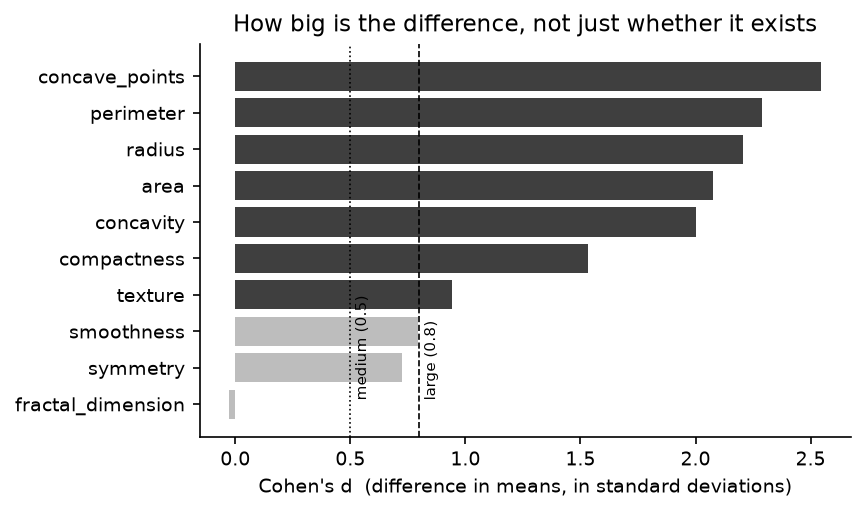

In [10]:
order = effects.sort_values("cohens_d")

fig, ax = plt.subplots(figsize=(5.6, 3.4))
ax.barh(order.index, order["cohens_d"],
        color=[HONEST if v > 0.8 else "#bdbdbd" for v in order["cohens_d"]])
ax.axvline(0.8, ls="--", c="k", lw=0.8)
ax.axvline(0.5, ls=":", c="k", lw=0.8)
ax.text(0.82, 0.2, "large (0.8)", rotation=90, fontsize=7)
ax.text(0.52, 0.2, "medium (0.5)", rotation=90, fontsize=7)
ax.set_xlabel("Cohen's d  (difference in means, in standard deviations)")
ax.set_title("How big is the difference, not just whether it exists")
fig.savefig("figures/effect-sizes.png")
plt.show()

In [11]:
from sklearn.metrics import roc_auc_score

y_all = (df["diagnosis"] == "M").astype(int)

# How well does the single best feature separate the classes, on its own?
single = pd.Series({c: roc_auc_score(y_all, df[c]) for c in df.columns.drop("diagnosis")})
print("best single features, by AUC:")
print(single.sort_values(ascending=False).head(5).round(4).to_string())
print("\nworst:")
print(single.sort_values().head(3).round(4).to_string())

best single features, by AUC:
perimeter_worst         0.9755
radius_worst            0.9704
area_worst              0.9698
concave_points_worst    0.9667
concave_points_mean     0.9644

worst:
symmetry_se               0.4449
smoothness_se             0.4688
fractal_dimension_mean    0.4845


This is the point of the whole section. `concave_points_mean` has an effect size of 2.55 and a p-value with
seventy zeros — and as a single-feature classifier it reaches an AUC of 0.964, which sounds excellent and
still means it misranks a meaningful fraction of patient pairs.

**Statistical significance is not separability.** A difference can be certain, large, and still insufficient
to make a decision about an individual patient.

Which is why we need a model.

---
## 3. The first model: logistic regression

Nothing fancier. Not as a warm-up before the real thing — it is genuinely the right tool here, and you can
explain every part of it.

### What it actually does

Biologists already know this curve. If you have ever fitted a dose–response, you have fitted a sigmoid.
Logistic regression is the same S-shaped curve with two changes: the input is a weighted sum of several
measurements rather than one dose, and the output is read as a probability.

**Step 1 — combine the features into one score.** Multiply each feature by a weight, add them up, plus an
offset:

```
z  =  b0  +  b1 * radius  +  b2 * texture  +  ...  +  b30 * fractal_dimension_worst
```

The weights `b` are the **parameters**. Training means finding them.

**Step 2 — squash the score into a probability.** `z` can be any number; a probability must lie between 0
and 1. The **sigmoid** does that:

```
P(malignant)  =  1 / (1 + exp(-z))
```

`z = 0` gives 0.5; large positive `z` approaches 1, large negative approaches 0. The curve is steep in the
middle and flat at the ends — exactly right, because near the boundary small changes in measurement matter a
lot and far from it they barely matter.

**Step 3 — turn the probability into a decision.** Compare it with a **threshold**, conventionally 0.5.

Two footnotes on the maths. `z` is the **log-odds**, the logarithm of P/(1−P), so a weight of 1.4 means "one
standard deviation more of this feature multiplies the odds of malignancy by exp(1.4) ≈ 4". And *training*
concretely means **maximum likelihood**: choose the weights that make the observed diagnoses as probable as
possible, found by **gradient descent** — nudging every weight in the direction that reduces error, over and
over. Closer to curve-fitting in Prism than to anything mystical.

### Split the data before you touch it

Two conventions in the next cell, because nobody ever explains them.

`X` is capital because it is a table with many columns. `y` is lower case because it is a single column.
That is the only reason.

`(df["diagnosis"] == "M")` gives a column of `True`/`False`, and `.astype(int)` turns those into 1 and 0.
Malignant is 1 because malignant is the thing we are trying to detect. In machine learning the thing you
are looking for is always the **positive class**, whether or not it is good news.

In [12]:
from sklearn.model_selection import train_test_split

X = df.drop(columns="diagnosis")
y = (df["diagnosis"] == "M").astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

print(f"train: {X_train.shape[0]} samples, {y_train.sum()} malignant, prevalence {y_train.mean():.4f}")
print(f"test:  {X_test.shape[0]} samples, {y_test.sum()} malignant, prevalence {y_test.mean():.4f}")

train: 455 samples, 170 malignant, prevalence 0.3736
test:  114 samples, 42 malignant, prevalence 0.3684


Four decisions in that one call.

**`test_size=0.20`** — 455 samples to train on, 114 held back. The **test set** is data the model never sees
during fitting, used once at the very end to estimate performance on new patients.

**`stratify=y`** — keep the class ratio the same in both parts (37.4% and 36.8%). Without it a random split
can hand you an unrepresentative test set, and every metric shifts for no biological reason.

**`random_state=42`** — the split is random; fixing the seed makes it *reproducibly* random. Anyone
re-running this notebook gets the same split. This one argument is the difference between a result and an
anecdote.

**The order.** Split first. Nothing that learns anything from the data happens before this line.

> **The test set is a reagent you can use once.** Every time you look at test performance and then change
> something — a feature, a threshold, an algorithm — you have used the test set to make a decision, and it
> stops being an honest estimate of the future. It becomes part of training, laundered through you.

### Scaling, and why it is not optional

Article 2's finding 5: the columns differ in scale by a factor of ~25,000. Logistic regression is fitted by
an iterative optimiser, and wildly different scales make that optimisation badly behaved. Watch what happens
with default settings on the raw columns.

In [13]:
import warnings

from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression

# Capture the warning instead of hiding it -- this is what you would see in your own terminal.
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    unscaled = LogisticRegression(max_iter=100).fit(X_train, y_train)

for w in caught:
    print(f"{w.category.__name__}: {w.message}")

print(f"iterations used: {unscaled.n_iter_[0]} of a 100 limit")
print(f"converged:       {unscaled.n_iter_[0] < 100}")
print(f"test accuracy:   {unscaled.score(X_test, y_test):.4f}   <- from a fit that never finished")

STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
iterations used: 100 of a 100 limit
converged:       False
test accuracy:   0.9211   <- from a fit that never finished


It hit the iteration limit and stopped wherever it happened to be. The accuracy it reports is an accident.

**Standardisation** fixes it: for each column, subtract the mean and divide by the standard deviation, so
every feature has mean 0 and SD 1. Nothing biological is lost — you changed units, not information — and
every feature now gets a fair hearing.

The critical detail is *which* mean and standard deviation. They must come from the training set only, then
be applied unchanged to the test set. Computing them on all 569 rows lets test data influence training. A
**pipeline** makes that impossible by construction.

In [15]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

model = make_pipeline(
    StandardScaler(),                       # learns means and SDs — from training data only
    LogisticRegression(max_iter=5000),      # enough iterations to converge properly
)

model.fit(X_train, y_train)

print(f"training accuracy: {model.score(X_train, y_train):.4f}")
print(f"test accuracy:     {model.score(X_test, y_test):.4f}")
print(f"baseline (all benign): {1 - y_test.mean():.4f}")


training accuracy: 0.9868
test accuracy:     0.9649
baseline (all benign): 0.6316


A pipeline is a chain of steps treated as one object. `fit` teaches the scaler the training means and SDs;
`predict` reuses them. You cannot leak through it by accident, which is the entire point.

**Anything that learns from data belongs inside the pipeline** — scalers, imputers, feature selectors, PCA.

96.5% against a 63.2% floor. Before celebrating: that number still does not tell us whether the model is
good, because accuracy is the wrong question. Section 7.

In [16]:
# Every model in scikit-learn that can, will give you probabilities. Always ask for them.
probabilities = model.predict_proba(X_test)[:, 1]     # column 1 = P(class 1) = P(malignant)
predictions = (probabilities >= 0.5).astype(int)

preview = pd.DataFrame({
    "true": np.where(y_test == 1, "M", "B"),
    "P(malignant)": probabilities.round(3),
    "predicted": np.where(predictions == 1, "M", "B"),
}, index=X_test.index)

print("the ten least certain predictions:")
least_certain = np.argsort(np.abs(probabilities - 0.5))[:10]
print(preview.iloc[least_certain].to_string())

the ten least certain predictions:
         true  P(malignant) predicted
id                                   
879523      M         0.492         B
9112085     B         0.509         M
862548      M         0.576         M
874858      M         0.315         B
86135501    M         0.758         M
855138      M         0.762         M
9112366     B         0.235         B
8810158     B         0.222         B
925292      B         0.201         B
90291       M         0.852         M


Those are the patients that matter. A system that reports 0.51 as "malignant" with no further comment is
hiding the most important thing it knows.

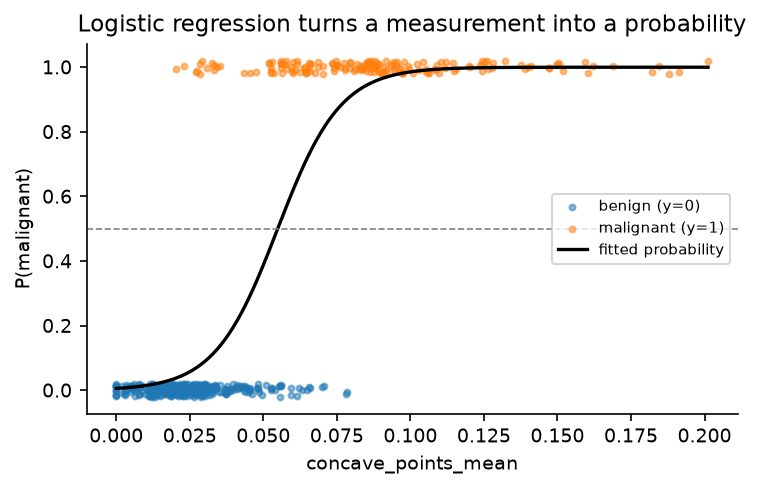

In [17]:
# A one-feature model, purely to draw the curve the maths describes.
feature = "concave_points_mean"
one_feature = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000))
one_feature.fit(X_train[[feature]], y_train)

grid = np.linspace(X[feature].min(), X[feature].max(), 300)
curve = one_feature.predict_proba(pd.DataFrame({feature: grid}))[:, 1]

jitter = np.random.default_rng(0).uniform(-0.02, 0.02, len(y_train))

fig, ax = plt.subplots(figsize=(5.6, 3.2))
ax.scatter(X_train.loc[y_train == 0, feature], 0 + jitter[y_train.values == 0],
           s=8, alpha=0.5, color=BENIGN, label="benign (y=0)")
ax.scatter(X_train.loc[y_train == 1, feature], 1 + jitter[y_train.values == 1],
           s=8, alpha=0.5, color=MALIGNANT, label="malignant (y=1)")
ax.plot(grid, curve, color="k", lw=1.6, label="fitted probability")
ax.axhline(0.5, ls="--", lw=0.8, c="grey")
ax.set_xlabel(feature)
ax.set_ylabel("P(malignant)")
ax.legend(fontsize=7, loc="center right")
ax.set_title("Logistic regression turns a measurement into a probability")
fig.savefig("figures/logistic-sigmoid.png")
plt.show()

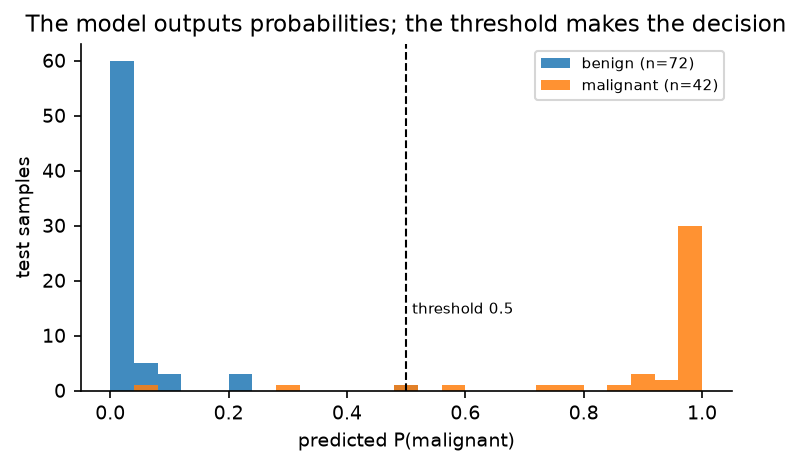

In [18]:
fig, ax = plt.subplots(figsize=(5.6, 3.0))
bins = np.linspace(0, 1, 26)
ax.hist(probabilities[y_test == 0], bins=bins, color=BENIGN, alpha=0.85,
        label=f"benign (n={(y_test == 0).sum()})")
ax.hist(probabilities[y_test == 1], bins=bins, color=MALIGNANT, alpha=0.85,
        label=f"malignant (n={(y_test == 1).sum()})")
ax.axvline(0.5, ls="--", c="k", lw=1)
ax.text(0.51, 14, "threshold 0.5", fontsize=7)
ax.set_xlabel("predicted P(malignant)")
ax.set_ylabel("test samples")
ax.legend(fontsize=7)
ax.set_title("The model outputs probabilities; the threshold makes the decision")
fig.savefig("figures/predicted-probabilities.png")
plt.show()

Most samples sit hard against 0 or 1 — those are easy, and the model knows it. A handful sit in the middle,
and those are the cases where the measurements genuinely are ambiguous.

### One patient, from measurements to probability

That is the theory. Here is the arithmetic, done by hand on one real person, so that nothing about the
model stays mysterious. Patient 8911670 is in the held-out test set; the model has never seen her.

Every measurement is standardised — expressed as how many standard deviations it sits above or below the
training-set average — then multiplied by its weight. Add the products, add the offset, push the total
through the sigmoid. That is the whole model.

In [19]:
# Three features to show in full. They are not the three largest contributions -- they are three
# whose direction is easy to read: bigger nucleus, more of it, pushes towards malignant.
SHOWN = ["radius_worst", "area_mean", "area_worst"]


def walk_through(patient_id, shown=SHOWN):
    """Carry one patient from raw measurements to a probability, by hand."""
    scaler = model.named_steps["standardscaler"]
    logistic = model.named_steps["logisticregression"]
    weights = pd.Series(logistic.coef_[0], index=X.columns)

    row = X_test.loc[[patient_id]]
    standardised = pd.Series(scaler.transform(row)[0], index=X.columns)
    contribution = standardised * weights
    offset = logistic.intercept_[0]

    table = pd.DataFrame({
        "raw value": row.iloc[0][shown],
        "standardised": standardised[shown].round(2),
        "weight": weights[shown].round(2),
        "contributes": contribution[shown].round(2),
    })

    z = offset + contribution.sum()
    probability = 1 / (1 + np.exp(-z))

    print(f"patient {patient_id}   true diagnosis: "
          f"{'malignant' if y_test.loc[patient_id] == 1 else 'benign'}")
    print(table.to_string())
    print(f"{'the other ' + str(30 - len(shown)) + ' features, together':<45}"
          f"{contribution.sum() - contribution[shown].sum():+.2f}")
    print(f"{'the offset b0':<45}{offset:+.2f}")
    print("-" * 58)
    print(f"{'score z':<45}{z:+.2f}")
    print(f"P(malignant) = 1 / (1 + e^-z) = {probability:.4f}   ->  "
          f"{'malignant' if probability >= 0.5 else 'benign'} at threshold 0.5")


walk_through(8911670)

patient 8911670   true diagnosis: malignant
              raw value  standardised  weight  contributes
radius_worst      19.96          0.74    0.90         0.66
area_mean       1102.00          1.23    0.44         0.54
area_worst      1236.00          0.59    0.90         0.53
the other 27 features, together              +2.13
the offset b0                                -0.24
----------------------------------------------------------
score z                                      +3.62
P(malignant) = 1 / (1 + e^-z) = 0.9739   ->  malignant at threshold 0.5


Thirty multiplications, one addition, one curve, one comparison. Nothing else happens. When someone says a
model "decided" something, that is what they mean.

Now the same three features on a second patient, and this one matters more.

In [20]:
walk_through(879523)

patient 879523   true diagnosis: malignant
              raw value  standardised  weight  contributes
radius_worst      17.77          0.29    0.90         0.26
area_mean        716.60          0.16    0.44         0.07
area_worst       989.50          0.17    0.90         0.15
the other 27 features, together              -0.27
the offset b0                                -0.24
----------------------------------------------------------
score z                                      -0.03
P(malignant) = 1 / (1 + e^-z) = 0.4916   ->  benign at threshold 0.5


Patient 879523 is malignant, and the model calls her benign — by eight thousandths of a probability point.
She is one of the three cancers this model misses. Hold on to her; she comes back twice, once when we count
the errors and once when we move the threshold.

### Reading the coefficients, carefully

The model is interpretable, so let us interpret it — and then look at the trap.

In [21]:
coefficients = pd.Series(
    model[-1].coef_[0], index=X.columns, name="weight"
).sort_values(key=abs, ascending=False)

table = coefficients.to_frame()
table["odds_multiplier_per_1_SD"] = np.exp(coefficients)

print("largest five weights (features are standardised, so these are comparable):")
print(table.head(5).round(3).to_string())
print("\nsmallest three:")
print(table.tail(3).round(3).to_string())

largest five weights (features are standardised, so these are comparable):
                     weight  odds_multiplier_per_1_SD
texture_worst         1.434                     4.196
radius_se             1.233                     3.433
symmetry_worst        1.061                     2.890
concave_points_mean   0.953                     2.593
concavity_worst       0.911                     2.488

smallest three:
                         weight  odds_multiplier_per_1_SD
concavity_se             -0.092                     0.912
fractal_dimension_mean   -0.081                     0.922
fractal_dimension_worst   0.055                     1.056


Two honest observations.

The `worst` columns dominate — the model independently rediscovered the pathologist's heuristic that the
most abnormal cells matter most. A satisfying sanity check.

But `concave_points_mean`, our champion from section 2 with an effect size of 2.55, sits fourth, below
`radius_se`, which is not a feature any cytologist would nominate. **This is not a biological finding. It is
an artefact of correlation.** When features correlate at 0.99 (finding 6), the fit can distribute weight
among them almost arbitrarily; shift the split slightly and the ranking reshuffles.

*Model weights are how the model computes. They are not what the biology means.*

---

# Now run the controls

We have a model and a number: 96.5%. A number on its own means nothing. Time to find out what it is worth.

## 4. Control 1 — the blank

The simplest control there is. What score do you get for doing nothing? Predict "benign" for every single
patient — no measurements, no model — and see what the plate reads with nothing in it.

In [22]:
for label, labels in [("whole dataset", y), ("training split", y_train), ("test split", y_test)]:
    print(f"predict benign for everyone, {label:<15} {1 - labels.mean():.4f}")

print()
print(f"our model on the test split                    {model.score(X_test, y_test):.4f}")

predict benign for everyone, whole dataset   0.6274
predict benign for everyone, training split  0.6264
predict benign for everyone, test split      0.6316

our model on the test split                    0.9649


That is the blank reading. Our model has to be compared against **63.2%**, not against zero.

The number moves slightly depending on which patients you look at — 62.7% across all 569, 63.2% in our
particular 114-patient test set. Same rule, different sample. That small wobble is itself a preview of the
next control.

This control is trivial to run and it is skipped constantly. It is the reason "our model is 95% accurate" is
meaningless on its own: if 95% of your patients are healthy, a model that says "healthy" to everyone scores
95% and has learned nothing at all.

---
## 5. Control 2 — the replicate

We have one number from one split. That is the weakest possible evidence, and here is the proof.

In [23]:
from sklearn.metrics import accuracy_score

accuracies = []
for seed in range(50):
    a, b, c, d_ = train_test_split(X, y, test_size=0.20, stratify=y, random_state=seed)
    fitted = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000)).fit(a, c)
    accuracies.append(accuracy_score(d_, fitted.predict(b)))

accuracies = np.array(accuracies)
print("the same pipeline, 50 different random 80/20 splits:")
print(f"  min  {accuracies.min():.4f}")
print(f"  max  {accuracies.max():.4f}")
print(f"  mean {accuracies.mean():.4f}   sd {accuracies.std():.4f}")

the same pipeline, 50 different random 80/20 splits:
  min  0.9386
  max  1.0000
  mean 0.9739   sd 0.0141


Nothing changed except which 114 patients were held back, and test accuracy moved by six points. A model
whose reported accuracy depends that strongly on an arbitrary seed cannot be described by a single number.

### Strategy 1: three-way split — train, validation, test

The two-way split has a gap. You have to make choices — which features, which algorithm, how strong the
regularisation — and comparing options on the test set spends it. So you split three ways:

- **Training set** — fit the parameters.
- **Validation set** — compare choices and pick the winner.
- **Test set** — touched once, at the very end, to report performance.

Clean and simple. Its problem with 569 samples is arithmetic: 60/20/20 leaves about 114 validation samples,
and a difference of two or three samples flips the comparison. Too small to choose on.

### Strategy 2: k-fold cross-validation

This is the one to internalise, and biologists already understand it: it is **technical replicates for model
evaluation**.

Split the training data into k equal parts (**folds**). Train on k−1 of them, evaluate on the one left out.
Repeat until every fold has been the held-out one exactly once. You get k estimates from k different held-out
sets, and every sample is used for evaluation exactly once.

In [24]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_validate(
    make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000)),
    X_train, y_train,                       # training data only. The test set stays untouched.
    cv=cv,
    scoring=["accuracy", "precision", "recall", "f1", "roc_auc"],
)

summary = pd.DataFrame({
    metric: {
        "mean": scores[f"test_{metric}"].mean(),
        "sd": scores[f"test_{metric}"].std(),
        "min": scores[f"test_{metric}"].min(),
        "max": scores[f"test_{metric}"].max(),
    }
    for metric in ["accuracy", "precision", "recall", "f1", "roc_auc"]
}).T

print(summary.round(4).to_string())
print("\nper-fold accuracy:", np.round(scores["test_accuracy"], 3))
print("per-fold recall:  ", np.round(scores["test_recall"], 3))

             mean      sd     min  max
accuracy   0.9736  0.0149  0.9560  1.0
precision  0.9771  0.0280  0.9429  1.0
recall     0.9529  0.0399  0.8824  1.0
f1         0.9640  0.0207  0.9375  1.0
roc_auc    0.9958  0.0047  0.9871  1.0

per-fold accuracy: [0.956 0.967 1.    0.978 0.967]
per-fold recall:   [0.882 0.971 1.    0.941 0.971]


**The spread is the point.** One fold scored a perfect 1.000 on accuracy; another 0.956. Recall ranged from
0.882 to 1.000 — twelve points. Run a single split, land on that first fold, and you would be telling people
your model is perfect.

Report the mean *and* the spread. Always. Same instinct as never reporting a single well without replicates.

**Repeated cross-validation** goes further: shuffle and repeat the whole procedure.

In [25]:
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score

repeated = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=1)
repeated_scores = cross_val_score(
    make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000)),
    X_train, y_train, cv=repeated, scoring="accuracy",
)

print(f"5 folds x 10 repeats = {len(repeated_scores)} estimates")
print(f"accuracy {repeated_scores.mean():.4f} +/- {repeated_scores.std():.4f}"
      f"   (range {repeated_scores.min():.4f} to {repeated_scores.max():.4f})")

5 folds x 10 repeats = 50 estimates
accuracy 0.9727 +/- 0.0153   (range 0.9341 to 1.0000)


**97.3% ± 1.5%** is an honest description of this model on this dataset.

### Strategy 3: tuning hyperparameters, inside cross-validation

**Hyperparameters** are settings you choose rather than fit. The main one here is `C`, which controls
**regularisation** — a penalty on large weights, added to the loss the optimiser minimises. It makes the
model prefer a simpler explanation and stops it becoming over-confident about any single feature.

- **L2** (ridge, the default) penalises the sum of *squared* weights. It shrinks every weight toward zero,
  keeping all features but taming them. With correlated features it spreads weight across the group.
- **L1** (lasso) penalises the sum of *absolute* weights, and has a striking property: it drives some weights
  to **exactly zero**. It performs feature selection as part of fitting.

Small `C` = strong penalty. Large `C` = weak penalty. Choose it by search — inside cross-validation, on the
training data.

In [26]:
from sklearn.model_selection import GridSearchCV

search = GridSearchCV(
    make_pipeline(
        StandardScaler(),
        # scikit-learn 1.8 renamed this argument: penalty="l1" is now spelled l1_ratio=1.
        # Both give identical results; penalty= is the spelling older versions understand,
        # so it is used here and the deprecation warning is silenced.
        LogisticRegression(penalty="l1", solver="liblinear", max_iter=20000, random_state=0),
    ),
    {"logisticregression__C": [0.01, 0.03, 0.1, 0.3, 1, 3, 10]},
    cv=cv,
    scoring="roc_auc",
)

with warnings.catch_warnings():
    warnings.simplefilter("ignore", FutureWarning)
    warnings.simplefilter("ignore", UserWarning)
    search.fit(X_train, y_train)

l1_weights = pd.Series(search.best_estimator_[-1].coef_[0], index=X.columns)
kept = l1_weights[l1_weights != 0]

print(f"best C:            {search.best_params_['logisticregression__C']}")
print(f"cross-validated ROC-AUC: {search.best_score_:.4f}")
print(f"test set:          {search.score(X_test, y_test):.4f} (roc_auc)"
      f"  {accuracy_score(y_test, search.predict(X_test)):.4f} (accuracy)")
print(f"\nfeatures kept by L1: {len(kept)} of {len(l1_weights)}")
print(kept.sort_values(key=abs, ascending=False).round(3).to_string())

best C:            1
cross-validated ROC-AUC: 0.9960
test set:          0.9967 (roc_auc)  0.9737 (accuracy)

features kept by L1: 14 of 30
radius_se               2.672
area_worst              2.246
texture_worst           2.075
concave_points_mean     1.903
radius_worst            1.441
concavity_worst         1.087
compactness_se         -0.989
texture_se             -0.693
symmetry_worst          0.653
concave_points_worst    0.361
smoothness_se           0.334
fractal_dimension_se   -0.285
smoothness_worst        0.229
concave_points_se       0.188


Fourteen features instead of thirty, and very slightly *better* on the test set. Note what the search did and
did not touch: it cross-validated on training data only, and the test set played no part in choosing `C`.

### Strategy 4: handling class imbalance

37% malignant is mild imbalance — enough to notice, not enough to break anything. Still, the model minimises
total error by default, and with benign samples in the majority, total error is cheapest to reduce by leaning
benign. Which is exactly the wrong direction clinically.

In [27]:
from sklearn.metrics import precision_score, recall_score

balanced = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=5000, class_weight="balanced"),
).fit(X_train, y_train)

comparison = pd.DataFrame({
    "default": {
        "accuracy": model.score(X_test, y_test),
        "precision": precision_score(y_test, model.predict(X_test)),
        "recall": recall_score(y_test, model.predict(X_test)),
    },
    "class_weight='balanced'": {
        "accuracy": balanced.score(X_test, y_test),
        "precision": precision_score(y_test, balanced.predict(X_test)),
        "recall": recall_score(y_test, balanced.predict(X_test)),
    },
})
print(comparison.round(4).to_string())

           default  class_weight='balanced'
accuracy    0.9649                   0.9737
precision   0.9750                   0.9756
recall      0.9286                   0.9524


`class_weight="balanced"` makes each malignant sample count more in the loss, in inverse proportion to how
common its class is. Recall rises from 92.9% to 95.2% — one fewer missed cancer — with precision essentially
unchanged.

For severe imbalance (1% positives) this stops being a tweak and becomes the central problem, alongside
resampling methods and metrics that ignore the majority class. Not our situation, but recognise it when it
arrives.

### The strategies, summarised

| Situation | Strategy |
| --- | --- |
| Any supervised problem | Split before you look. Stratify. Fix the seed. |
| Estimating performance | k-fold CV, report mean **and** spread |
| Small dataset (like ours) | Repeated stratified CV; a single split is not evidence |
| Choosing between options | Cross-validate on training data; never on test |
| Tuning hyperparameters | Grid search inside CV |
| Any preprocessing step | Inside a pipeline, so it refits every fold |
| Imbalanced classes | `class_weight`, plus metrics that respect the minority |
| Final number to report | Test set, once, with a confidence interval |

---

## 6. Control 3 — the negative control

The blank told us what "doing nothing" scores. The replicates told us how much the number wobbles. Neither
answers the question that should worry you most:

> *What score would I get if there were definitely no relationship between these measurements and the
> diagnosis?*

You cannot answer that by thinking about it. You answer it by experiment. Take the diagnosis column and
**shuffle it** — deal the labels out to the wrong patients at random. Every measurement stays where it is;
only the answer key gets scrambled. Now there is nothing to learn, by construction, and any pattern the
model finds is noise.

Fit the whole pipeline on the shuffled labels, cross-validate, write down the accuracy. Then do it again,
a thousand times.

This cell fits the model 5,000 times, so it is the slowest one in the notebook — well under a minute if
`n_jobs=-1` has several cores to use, a few minutes on a modest laptop. It is the most worthwhile time you
will spend here.

In [28]:
from sklearn.model_selection import permutation_test_score

permutation_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

observed, null_scores, p_value = permutation_test_score(
    make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000)),
    X_train, y_train,
    scoring="accuracy", cv=permutation_cv,
    n_permutations=1000, random_state=0, n_jobs=-1,
)

print(f"observed cross-validated accuracy   {observed:.3f}")
print()
print("shuffled labels, 1,000 runs:")
print(f"  mean                              {null_scores.mean():.3f}")
print(f"  standard deviation                {null_scores.std():.3f}")
print(f"  range                             {null_scores.min():.3f} to {null_scores.max():.3f}")
print(f"  95th percentile                   {np.percentile(null_scores, 95):.3f}")
print()
print(f"runs scoring at least {observed:.3f}         {(null_scores >= observed).sum()} of 1,000")
print(f"p-value                             {p_value:.3f}")
print(f"standard deviations above the null  "
      f"{(observed - null_scores.mean()) / null_scores.std():.1f}")

observed cross-validated accuracy   0.974

shuffled labels, 1,000 runs:
  mean                              0.597
  standard deviation                0.015
  range                             0.558 to 0.644
  95th percentile                   0.622

runs scoring at least 0.974         0 of 1,000
p-value                             0.001
standard deviations above the null  25.7


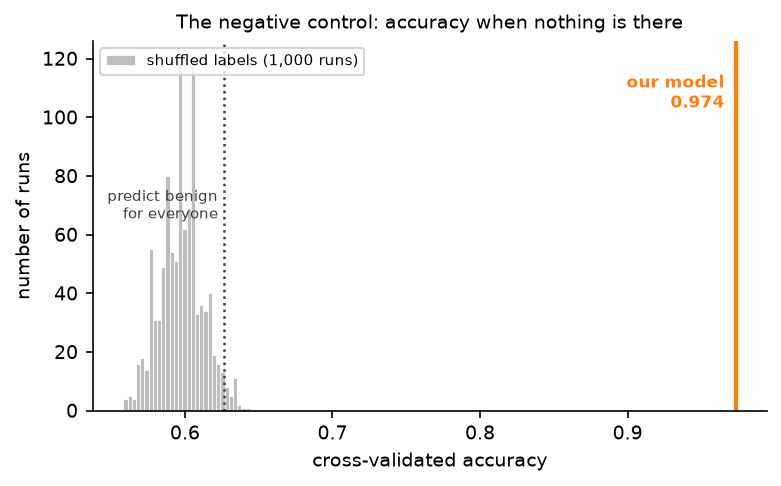

In [29]:
fig, ax = plt.subplots(figsize=(5.8, 3.2))
ax.hist(null_scores, bins=30, color="#bdbdbd", edgecolor="white", linewidth=0.4,
        label="shuffled labels (1,000 runs)")
top = ax.get_ylim()[1]

ax.axvline(1 - y_train.mean(), ls=":", c=HONEST, lw=1.2)
ax.text(1 - y_train.mean() - 0.004, top * 0.52, "predict benign\nfor everyone",
        fontsize=7, ha="right", color=HONEST)

ax.axvline(observed, color=MALIGNANT, lw=2)
ax.text(observed - 0.008, top * 0.82, f"our model\n{observed:.3f}",
        fontsize=8, ha="right", color=MALIGNANT, weight="bold")

ax.set_xlabel("cross-validated accuracy")
ax.set_ylabel("number of runs")
ax.set_title("The negative control: accuracy when nothing is there", fontsize=9)
ax.legend(fontsize=7, loc="upper left")
fig.savefig("figures/permutation-null.png")
plt.show()

Three lessons in one figure.

**Our model sits about 25 standard deviations above the noise floor.** Not one of the thousand shuffled runs
came near it. That empty gap between "nothing" and "our model" is the result.

**"No signal" scores about 0.60, not 0.50.** With the labels shuffled the model has nothing real to work
with, so it drifts toward guessing the common class — and the common class is 63% of the data. If your
intuition said a meaningless model should score 50%, that error is exactly the size of the mistake people
make when they call 65% accuracy "better than chance".

**A shuffled model still reached about 0.64.** That is the number to remember. On this dataset, with nothing
whatsoever to find, an ordinary analysis can produce 64% accuracy — above the do-nothing baseline, modest,
plausible, and indistinguishable from noise.

Our dataset has 569 samples and 30 features, so the answer was never in doubt. Yours may have 60 samples and
20,000 genes, where the noise floor is far higher than you would guess and this test is the only thing that
tells you where it sits. It is a scrambled-probe control. It is a no-template control. You already accept
this logic; this is the same move, applied to a model.

---
## 7. Accuracy is not enough

96.5% accuracy. Here is what that number conceals.

In [30]:
from sklearn.metrics import classification_report, confusion_matrix

cm = confusion_matrix(y_test, predictions)
tn, fp, fn, tp = cm.ravel()

print(f"true negatives  {tn:3d}   benign, correctly left alone")
print(f"false positives {fp:3d}   benign, called malignant     -> unnecessary procedures and fear")
print(f"false negatives {fn:3d}   MALIGNANT, called benign     -> a cancer sent home untreated")
print(f"true positives  {tp:3d}   malignant, correctly caught")
print()
print(classification_report(y_test, predictions, target_names=["benign", "malignant"], digits=3))

true negatives   71   benign, correctly left alone
false positives   1   benign, called malignant     -> unnecessary procedures and fear
false negatives   3   MALIGNANT, called benign     -> a cancer sent home untreated
true positives   39   malignant, correctly caught

              precision    recall  f1-score   support

      benign      0.959     0.986     0.973        72
   malignant      0.975     0.929     0.951        42

    accuracy                          0.965       114
   macro avg      0.967     0.957     0.962       114
weighted avg      0.965     0.965     0.965       114



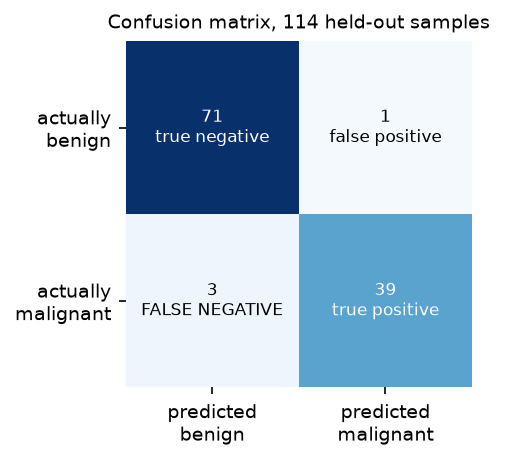

In [31]:
fig, ax = plt.subplots(figsize=(3.4, 3.0))
ax.imshow(cm, cmap="Blues", vmin=0, vmax=cm.max())
labels = [["true negative", "false positive"], ["FALSE NEGATIVE", "true positive"]]
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i, j]}\n{labels[i][j]}", ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=8)
ax.set_xticks([0, 1], ["predicted\nbenign", "predicted\nmalignant"])
ax.set_yticks([0, 1], ["actually\nbenign", "actually\nmalignant"])
ax.set_title(f"Confusion matrix, {len(y_test)} held-out samples", fontsize=9)
for spine in ax.spines.values():
    spine.set_visible(False)
fig.savefig("figures/confusion-matrix.png")
plt.show()

Four errors in 114 samples. Article 2 insisted they are not the same error:

- **1 false positive** — a benign mass called malignant. Further procedures, possibly surgery, certainly
  weeks of fear, and cost.
- **3 false negatives** — malignant masses called benign. Three patients sent home with a growing cancer and
  a piece of paper telling them not to worry.

Accuracy adds those together and divides by 114. It treats them as interchangeable. They are not.

### The metrics, in plain words

Every one of these is a fraction. The only thing to keep straight is *what the denominator is*.

| Metric | Definition | The question it answers |
| --- | --- | --- |
| **Accuracy** | correct / all | How often is it right? |
| **Precision** (PPV) | TP / (TP + FP) | When it says malignant, how often is that true? |
| **Recall** (sensitivity, TPR) | TP / (TP + FN) | Of all real cancers, how many did it catch? |
| **Specificity** (TNR) | TN / (TN + FP) | Of all benign cases, how many were left alone? |
| **F1** | harmonic mean of precision and recall | One number when you need one number |
| **NPV** | TN / (TN + FN) | When it says benign, how often is that true? |

If **sensitivity** and **specificity** feel familiar, that is because they are the language of diagnostic
assay validation. Recall *is* sensitivity. You already know half this vocabulary under other names.

### The three the model missed

We can do better than counting them. Here they are, with the measurement article 2 warned us about.

In [32]:
missed = X_test.index[(y_test == 1) & (probabilities < 0.5)]

report = pd.DataFrame({
    "P(malignant)": pd.Series(probabilities, index=X_test.index)[missed].round(3),
    "radius_mean": X_test.loc[missed, "radius_mean"],
    "concave_points_mean": X_test.loc[missed, "concave_points_mean"],
})
print(report.to_string())

benign_radius = df.loc[df.diagnosis == "B", "radius_mean"]
print()
print(f"benign radius_mean in this dataset runs {benign_radius.min():.2f} to {benign_radius.max():.2f}")
print("every missed cancer sits inside that range:",
      bool((X_test.loc[missed, "radius_mean"] <= benign_radius.max()).all()))

        P(malignant)  radius_mean  concave_points_mean
id                                                    
859983         0.061        13.80              0.05069
874858         0.315        14.22              0.06618
879523         0.492        15.12              0.04079

benign radius_mean in this dataset runs 6.98 to 17.85
every missed cancer sits inside that range: True


This is not a bug. It is finding 4 arriving in person. Article 2 told us that no cut-off on nuclear size
separates these classes, and that some patients live in the region where the measurements genuinely do not
distinguish. These three women are those patients.

And patient 879523 is there at 0.492, on the wrong side of a 0.5 threshold by 0.008. That is not a modelling
failure. It is a threshold decision, and we made it without thinking about it.

In [33]:
metrics = {
    "accuracy":    (tp + tn) / (tp + tn + fp + fn),
    "precision":   tp / (tp + fp),
    "recall":      tp / (tp + fn),
    "specificity": tn / (tn + fp),
    "npv":         tn / (tn + fn),
}
metrics["f1"] = 2 * metrics["precision"] * metrics["recall"] / (metrics["precision"] + metrics["recall"])

for name, value in metrics.items():
    print(f"{name:<12} {value:.4f}")

accuracy     0.9649
precision    0.9750
recall       0.9286
specificity  0.9861
npv          0.9595
f1           0.9512


The two that carry the consequences here:

- **Recall** is the missed-cancer metric. Every point you give up is a patient going home undiagnosed.
- **Precision** is the needless-intervention metric. Every point you give up is a healthy patient getting a
  workup they did not need.

They pull against each other, and no amount of mathematics resolves the tension. It is resolved by deciding
which error you are less willing to make — a clinical and ethical judgement that belongs to people, not to
the model.

### Metrics that do not need a threshold

Precision and recall depend on the 0.5 cut-off. Two metrics judge the model's **ranking** instead, across all
thresholds at once.

ROC-AUC:           0.9960
average precision: 0.9943
prevalence (the PR baseline): 0.3684


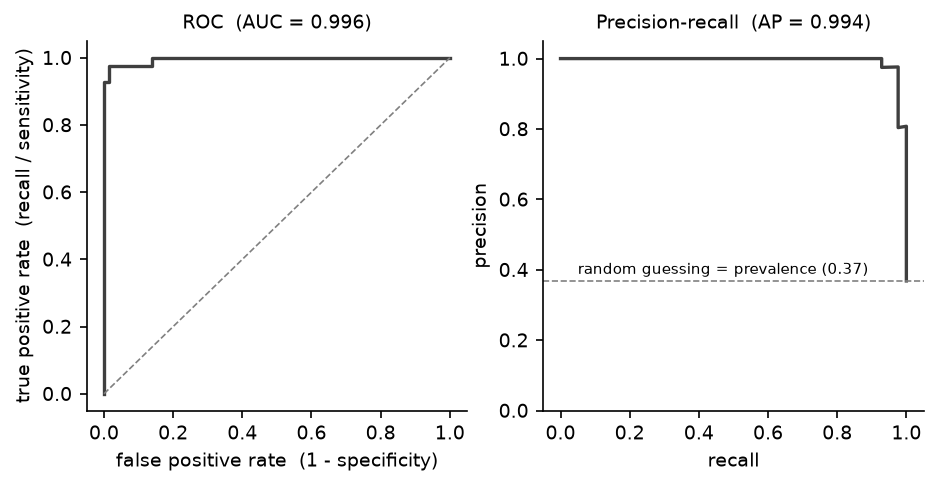

In [34]:
from sklearn.metrics import average_precision_score, precision_recall_curve, roc_curve

roc_auc = roc_auc_score(y_test, probabilities)
avg_precision = average_precision_score(y_test, probabilities)

print(f"ROC-AUC:           {roc_auc:.4f}")
print(f"average precision: {avg_precision:.4f}")
print(f"prevalence (the PR baseline): {y_test.mean():.4f}")

fpr, tpr, _ = roc_curve(y_test, probabilities)
precision_curve, recall_curve, _ = precision_recall_curve(y_test, probabilities)

fig, axs = plt.subplots(1, 2, figsize=(7.2, 3.2))
axs[0].plot(fpr, tpr, color=HONEST, lw=1.6)
axs[0].plot([0, 1], [0, 1], ls="--", c="grey", lw=0.8)
axs[0].set_xlabel("false positive rate  (1 - specificity)")
axs[0].set_ylabel("true positive rate  (recall / sensitivity)")
axs[0].set_title(f"ROC  (AUC = {roc_auc:.3f})", fontsize=9)

axs[1].plot(recall_curve, precision_curve, color=HONEST, lw=1.6)
axs[1].axhline(y_test.mean(), ls="--", c="grey", lw=0.8)
axs[1].text(0.05, y_test.mean() + 0.02, "random guessing = prevalence (0.37)", fontsize=7)
axs[1].set_xlabel("recall")
axs[1].set_ylabel("precision")
axs[1].set_ylim(0, 1.05)
axs[1].set_title(f"Precision-recall  (AP = {avg_precision:.3f})", fontsize=9)
fig.savefig("figures/roc-and-pr-curves.png")
plt.show()

**ROC-AUC = 0.996** has a beautifully concrete interpretation: **the probability that the model gives a
randomly chosen malignant sample a higher score than a randomly chosen benign one.** 0.5 is coin-flipping,
1.0 is a perfect ranking. Ours would rank a random pair correctly 996 times in 1,000.

**Average precision (PR-AUC) = 0.994** ignores true negatives entirely, which matters when the positive class
is rare. In a screening population where 1% of masses are malignant, a model can post a superb ROC-AUC while
its positive predictions are mostly false alarms — because there are so many benign cases that even a small
false positive *rate* produces a flood of false positives. The PR curve exposes that.

ROC-AUC for balanced comparisons; PR-AUC when the positive class is rare and chasing it is expensive.

### Moving the threshold moves the harm

The threshold is not part of the model. It is a policy dial, and you are allowed to turn it.

In [35]:
rows = []
for threshold in [0.70, 0.50, 0.30, 0.20, 0.10, 0.05]:
    predicted = (probabilities >= threshold).astype(int)
    c = confusion_matrix(y_test, predicted)
    rows.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_test, predicted),
        "precision": precision_score(y_test, predicted, zero_division=0),
        "recall": recall_score(y_test, predicted),
        "false_negatives": c[1, 0],
        "false_positives": c[0, 1],
    })

print(pd.DataFrame(rows).set_index("threshold").round(3).to_string())

           accuracy  precision  recall  false_negatives  false_positives
threshold                                                               
0.70          0.965      1.000   0.905                4                0
0.50          0.965      0.975   0.929                3                1
0.30          0.982      0.976   0.976                1                1
0.20          0.956      0.911   0.976                1                4
0.10          0.947      0.891   0.976                1                5
0.05          0.904      0.792   1.000                0               11


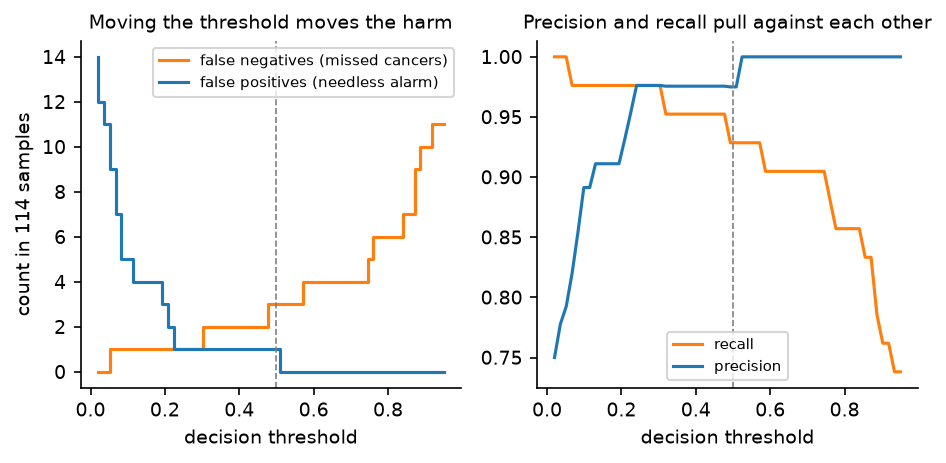

In [36]:
sweep = np.linspace(0.02, 0.95, 60)
false_negatives, false_positives, recalls, precisions = [], [], [], []
for threshold in sweep:
    predicted = (probabilities >= threshold).astype(int)
    c = confusion_matrix(y_test, predicted)
    false_negatives.append(c[1, 0])
    false_positives.append(c[0, 1])
    recalls.append(recall_score(y_test, predicted))
    precisions.append(precision_score(y_test, predicted, zero_division=1))

fig, axs = plt.subplots(1, 2, figsize=(7.2, 3.0))
axs[0].step(sweep, false_negatives, color=MALIGNANT, label="false negatives (missed cancers)")
axs[0].step(sweep, false_positives, color=BENIGN, label="false positives (needless alarm)")
axs[0].axvline(0.5, ls="--", c="grey", lw=0.8)
axs[0].set_xlabel("decision threshold")
axs[0].set_ylabel(f"count in {len(y_test)} samples")
axs[0].legend(fontsize=7)
axs[0].set_title("Moving the threshold moves the harm", fontsize=9)

axs[1].plot(sweep, recalls, color=MALIGNANT, label="recall")
axs[1].plot(sweep, precisions, color=BENIGN, label="precision")
axs[1].axvline(0.5, ls="--", c="grey", lw=0.8)
axs[1].set_xlabel("decision threshold")
axs[1].legend(fontsize=7)
axs[1].set_title("Precision and recall pull against each other", fontsize=9)
fig.savefig("figures/threshold-tradeoff.png")
plt.show()

Read the top and bottom rows of that table. At 0.70 you never falsely alarm anyone and miss four cancers. At
0.05 you miss nothing and send eleven healthy people for unnecessary follow-up. Same model, same weights,
same 114 patients. The only thing that changed is a number you chose.

For a triage tool where every flagged case gets a confirmatory biopsy anyway, the bottom row may well be
correct — eleven extra biopsies to catch four extra cancers is a trade many clinicians would take without
hesitation. That is defensible *because it was decided*. Leaving the threshold at 0.5 because it is the
default is not a decision at all.

> **One warning, and it applies to the table above.** The 0.30 row looks best — 98.2% accuracy, one error of
> each kind. I found it by trying thresholds on the *test* set, which means I used the test set to make a
> choice, which means 98.2% is no longer an honest estimate of anything. Done properly, the threshold is
> chosen on validation folds and then applied once to the test set. I left the mistake visible because it is
> the single easiest way to fool yourself, and it always happens exactly like this: innocently, one small
> look at a time.

### How certain is 96.5%?

One more number almost nobody reports. Our estimate rests on 114 samples. What is the uncertainty on it?

In [37]:
def wilson_interval(successes, n, z=1.96):
    # Wilson score interval: better than the textbook formula when p is near 0 or 1.
    p = successes / n
    denominator = 1 + z**2 / n
    centre = (p + z**2 / (2 * n)) / denominator
    half_width = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / denominator
    return centre - half_width, centre + half_width


correct = tn + tp
acc_lo, acc_hi = wilson_interval(correct, len(y_test))
rec_lo, rec_hi = wilson_interval(tp, tp + fn)

print(f"accuracy {correct}/{len(y_test)} = {correct / len(y_test):.3f}"
      f"    95% CI {acc_lo:.3f} to {acc_hi:.3f}")
print(f"recall   {tp}/{tp + fn} = {tp / (tp + fn):.3f}"
      f"      95% CI {rec_lo:.3f} to {rec_hi:.3f}")

accuracy 110/114 = 0.965    95% CI 0.913 to 0.986
recall   39/42 = 0.929      95% CI 0.810 to 0.975


The honest statement is **somewhere between 91% and 99%**. And recall — the metric that matters most
clinically — is estimated from 42 malignant samples, giving an interval nineteen points wide. Not because the
model is bad, but because 42 is a small number.

A biologist needs no lecture about n. The habit is simply to apply it to model performance as readily as to a
mean.

---
## 8. Control 4 — the sham, and the two ways models lie

This section is scientific skepticism, pointed somewhere new. The instinct is already yours — a result that
looks too clean makes you suspicious, and you go looking for the artefact. There are only a few artefacts to
learn.

### Overfitting

**Overfitting** is a model learning the noise in the training set instead of the pattern. It performs
beautifully on the data it was fitted to and poorly on anything new: it has memorised the answers rather than
learned the biology.

The evidence is always the same shape — **a large gap between training and held-out performance**.

In [38]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import PolynomialFeatures
from sklearn.tree import DecisionTreeClassifier

candidates = {
    "decision tree, unlimited depth": DecisionTreeClassifier(random_state=0),
    "1-nearest neighbour": make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=1)),
    "logistic on 495 inputs (features + squares + products)": make_pipeline(
        StandardScaler(),
        PolynomialFeatures(degree=2, include_bias=False),
        StandardScaler(),
        LogisticRegression(C=1e6, max_iter=20000),
    ),
    "decision tree, max_depth=2": DecisionTreeClassifier(max_depth=2, random_state=0),
    "logistic regression, 30 features (ours)": make_pipeline(
        StandardScaler(), LogisticRegression(max_iter=5000)
    ),
}

rows = []
with warnings.catch_warnings():
    warnings.simplefilter("ignore", ConvergenceWarning)
    for name, candidate in candidates.items():
        candidate.fit(X_train, y_train)
        train_acc = candidate.score(X_train, y_train)
        test_acc = candidate.score(X_test, y_test)
        rows.append({"model": name, "train": train_acc, "test": test_acc, "gap": train_acc - test_acc})

print(pd.DataFrame(rows).set_index("model").round(3).to_string())

                                                        train   test    gap
model                                                                      
decision tree, unlimited depth                          1.000  0.930  0.070
1-nearest neighbour                                     1.000  0.930  0.070
logistic on 495 inputs (features + squares + products)  1.000  0.930  0.070
decision tree, max_depth=2                              0.954  0.921  0.033
logistic regression, 30 features (ours)                 0.987  0.965  0.022


Three models score a **perfect 1.000** on the training data, and all three are *worse* on new patients than
the simple model that never achieved a perfect training score.

An unlimited-depth tree can keep splitting until each leaf holds one patient. 1-nearest-neighbour literally
stores the training set. The 495-input model has more parameters than it has samples. Each of them can
memorise 455 rows, and memorising is not learning.

The mirror image is **underfitting** — a model too simple to capture a pattern that is really there. The
balance between them is the **bias–variance trade-off**: too simple and you miss the signal, too flexible and
you fit the noise.

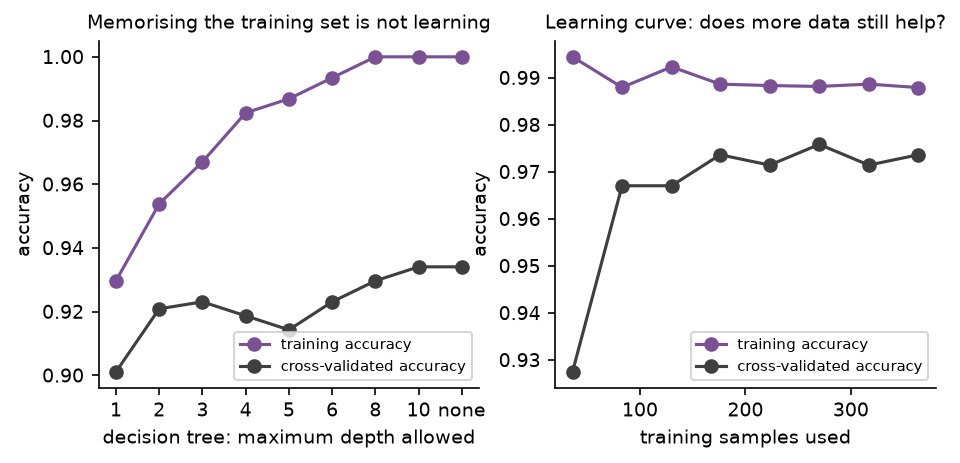

In [39]:
from sklearn.model_selection import learning_curve

depths = [1, 2, 3, 4, 5, 6, 8, 10, None]
train_by_depth, cv_by_depth = [], []
for depth in depths:
    tree = DecisionTreeClassifier(max_depth=depth, random_state=0).fit(X_train, y_train)
    train_by_depth.append(tree.score(X_train, y_train))
    cv_by_depth.append(
        cross_val_score(DecisionTreeClassifier(max_depth=depth, random_state=0), X_train, y_train, cv=cv).mean()
    )

sizes, train_scores, cv_scores = learning_curve(
    make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000)),
    X_train, y_train, train_sizes=np.linspace(0.1, 1.0, 8), cv=cv,
    scoring="accuracy", shuffle=True, random_state=0,
)

fig, axs = plt.subplots(1, 2, figsize=(7.2, 3.0))
positions = range(len(depths))
axs[0].plot(positions, train_by_depth, "o-", color=OPTIMISTIC, label="training accuracy")
axs[0].plot(positions, cv_by_depth, "o-", color=HONEST, label="cross-validated accuracy")
axs[0].set_xticks(list(positions), [str(d) if d else "none" for d in depths])
axs[0].set_xlabel("decision tree: maximum depth allowed")
axs[0].set_ylabel("accuracy")
axs[0].legend(fontsize=7)
axs[0].set_title("Memorising the training set is not learning", fontsize=9)

axs[1].plot(sizes, train_scores.mean(axis=1), "o-", color=OPTIMISTIC, label="training accuracy")
axs[1].plot(sizes, cv_scores.mean(axis=1), "o-", color=HONEST, label="cross-validated accuracy")
axs[1].set_xlabel("training samples used")
axs[1].set_ylabel("accuracy")
axs[1].legend(fontsize=7)
axs[1].set_title("Learning curve: does more data still help?", fontsize=9)
fig.savefig("figures/overfitting.png")
plt.show()

The left panel is the canonical picture: as the tree is allowed more depth, training accuracy climbs to a
perfect 1.000 while cross-validated accuracy flattens. Everything past the point where the curves separate is
fitting noise.

The right panel is a **learning curve** — performance against how much training data you use. It rises fast
to about 100 samples and then flattens, which is practical information: more samples of this kind would buy us
very little, so effort is better spent elsewhere. When the curve is still climbing at your maximum n,
collecting more data is the highest-value thing you can do.

### Data leakage

**Data leakage** is information from outside the training data influencing the model. It is more dangerous
than overfitting for one reason: overfitting shows up as a gap you can see, while leakage inflates *both*
numbers and leaves everything looking excellent.

Here is the demonstration I wish someone had shown me on day one. Five thousand columns of pure random noise,
no relationship to diagnosis, nothing whatsoever to find.

In [40]:
from sklearn.feature_selection import SelectKBest, f_classif

rng = np.random.default_rng(42)
noise = pd.DataFrame(
    rng.normal(size=(len(y_all), 5000)),
    index=df.index,
    columns=[f"noise_{i}" for i in range(5000)],
)

# THE WRONG WAY: pick the 10 columns most associated with diagnosis using ALL the labels,
# then cross-validate on those 10. This feels completely natural. It is not.
selector = SelectKBest(f_classif, k=10).fit(noise, y_all)
leaky = cross_val_score(
    make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000)),
    noise.loc[:, selector.get_support()], y_all, cv=cv, scoring="accuracy",
)

# THE RIGHT WAY: selection is a step in the pipeline, so it refits inside every fold
# using only that fold's training part.
honest = cross_val_score(
    make_pipeline(SelectKBest(f_classif, k=10), StandardScaler(), LogisticRegression(max_iter=5000)),
    noise, y_all, cv=cv, scoring="accuracy",
)

print(f"select on ALL data, then cross-validate : {leaky.mean():.4f}   <- invented from nothing")
print(f"select INSIDE each fold                 : {honest.mean():.4f}")
print(f"majority-class baseline                 : {max(y_all.mean(), 1 - y_all.mean()):.4f}")
print(f"the truth                               : no signal exists")

select on ALL data, then cross-validate : 0.6959   <- invented from nothing
select INSIDE each fold                 : 0.5747
majority-class baseline                 : 0.6274
the truth                               : no signal exists


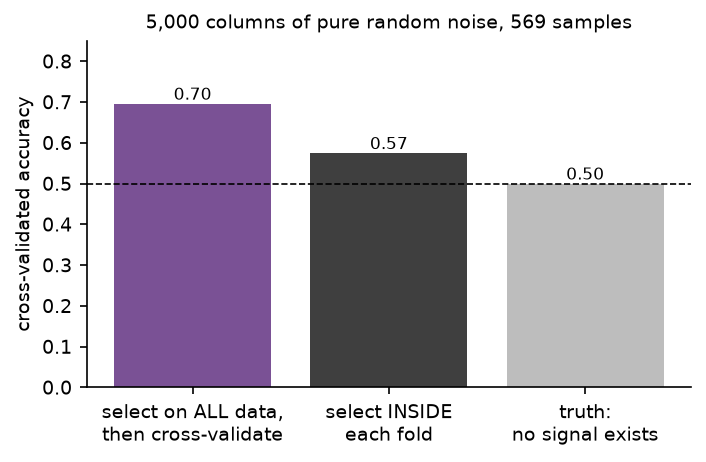

In [41]:
fig, ax = plt.subplots(figsize=(5.2, 3.0))
values = [leaky.mean(), honest.mean(), 0.5]
bars = ax.bar(
    ["select on ALL data,\nthen cross-validate", "select INSIDE\neach fold", "truth:\nno signal exists"],
    values, color=[OPTIMISTIC, HONEST, "#bdbdbd"],
)
for bar, value in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 0.01, f"{value:.2f}", ha="center", fontsize=8)
ax.axhline(0.5, ls="--", c="k", lw=0.8)
ax.set_ylim(0, 0.85)
ax.set_ylabel("cross-validated accuracy")
ax.set_title("5,000 columns of pure random noise, 569 samples", fontsize=9)
fig.savefig("figures/leakage-noise.png")
plt.show()

**69.6% accuracy out of pure noise** — and above the 62.7% majority-class baseline, so it does not even look
suspicious. Where did it come from? With 5,000 random columns, some correlate with diagnosis by chance.
Choosing them by looking at *all* the labels — including the ones in the held-out folds — smuggles the answers
into the feature set. The cross-validation that follows is theatre; the folds were compromised before it
started.

Do the selection inside each fold and the illusion collapses to 57.5%, which is *below* baseline — the honest
verdict on ten noise columns.

Now scale that up: **20,000 genes, 60 patients, and a signature selected on the full cohort.** This is not a
hypothetical failure mode. It is one of the most common reasons published biomarker signatures fail to
replicate.

Two more leaks, demonstrated rather than described.

In [42]:
# LEAK: fitting the scaler on all 569 rows, so test rows influence the training transformation.
scaled_everything = pd.DataFrame(
    StandardScaler().fit_transform(X), index=X.index, columns=X.columns
)
a, b, c, d_ = train_test_split(scaled_everything, y, test_size=0.20, stratify=y, random_state=42)
leaky_scaling = LogisticRegression(max_iter=5000).fit(a, c).score(b, d_)

print(f"scaler fitted on all 569 rows: test accuracy {leaky_scaling:.4f}")
print(f"scaler fitted on train only:   test accuracy {model.score(X_test, y_test):.4f}")
print("\nIdentical. And that is exactly why the rule has to be structural rather than judged case by case:")
print("you cannot see this leak by looking at the number. Put the scaler in a pipeline and it cannot happen.")

scaler fitted on all 569 rows: test accuracy 0.9649
scaler fitted on train only:   test accuracy 0.9649

Identical. And that is exactly why the rule has to be structural rather than judged case by case:
you cannot see this leak by looking at the number. Put the scaler in a pipeline and it cannot happen.


In [43]:
# LEAK: the same sample on both sides of the split. Duplicate rows, one patient sampled twice,
# two slides from one tumour, technical replicates split at random.
knn = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=1)).fit(X_train, y_train)

polluted_X = pd.concat([X_test, X_train.iloc[:60]])
polluted_y = pd.concat([y_test, y_train.iloc[:60]])

print(f"1-NN on a clean test set:                {knn.score(X_test, y_test):.4f}")
print(f"1-NN with 60 training rows copied in:    {knn.score(polluted_X, polluted_y):.4f}")
print(f"1-NN on those 60 copied rows alone:      {knn.score(X_train.iloc[:60], y_train.iloc[:60]):.4f}")
print("\nIt does not recognise the biology. It recognises the row. Split by PATIENT, never by row.")

1-NN on a clean test set:                0.9298
1-NN with 60 training rows copied in:    0.9540
1-NN on those 60 copied rows alone:      1.0000

It does not recognise the biology. It recognises the row. Split by PATIENT, never by row.


Two more worth memorising, which this dataset is too clean to demonstrate:

**A feature that encodes the answer.** If the file had contained "date of mastectomy" or "referred to
oncology", a model would find it instantly and score ~100%, having learned only that treated patients had
cancer. Ask of every feature: *would this value have been available, in this form, at the moment the
prediction needs to be made?*

**Using the test set more than once.** Including the way I did in section 7. Every look is a decision, and
decisions are training.

### The control panel

Before I believe a model of my own:

- [ ] Is there a **baseline** to beat, and does the model beat it? (63% here)
- [ ] Was the data split **before** anything else happened?
- [ ] Is every learned preprocessing step **inside** a pipeline?
- [ ] Are the numbers from **cross-validation with a spread**, not one split?
- [ ] Has the **test set** been used exactly once?
- [ ] Is the **train–test gap** small?
- [ ] Could any feature be a **proxy for the label**, or unavailable at prediction time?
- [ ] Could the same patient appear in both **train and test**?
- [ ] Do the metrics match the **consequences**, not just accuracy?
- [ ] Does the result **agree with the biology** — and if not, do I know why?

Fail one of these and the number means nothing. Better to find that out yourself than to have someone find it
after you have presented it.

---
## 9. Do we really need all thirty features?

Article 2's finding 6 said the thirty columns hold far fewer than thirty independent facts. Time to act on it.

**Feature selection** means keeping a subset of the original columns — with the selection inside the pipeline,
per section 8.

In [44]:
rows = []
for k in [1, 2, 3, 5, 10, 15, 20, 25, 30]:
    selected = make_pipeline(
        SelectKBest(f_classif, k=k), StandardScaler(), LogisticRegression(max_iter=5000)
    )
    auc = cross_val_score(selected, X_train, y_train, cv=cv, scoring="roc_auc")
    acc = cross_val_score(selected, X_train, y_train, cv=cv, scoring="accuracy")
    rows.append({"features": k, "cv_roc_auc": auc.mean(), "sd": auc.std(), "cv_accuracy": acc.mean()})

feature_curve = pd.DataFrame(rows).set_index("features")
print(feature_curve.round(4).to_string())

          cv_roc_auc      sd  cv_accuracy
features                                 
1             0.9623  0.0212       0.9033
2             0.9827  0.0139       0.9407
3             0.9836  0.0127       0.9451
5             0.9850  0.0113       0.9429
10            0.9851  0.0120       0.9538
15            0.9884  0.0074       0.9429
20            0.9954  0.0047       0.9692
25            0.9959  0.0042       0.9736
30            0.9958  0.0047       0.9736


The honest reading: **two features get you to 0.983, and all thirty get you to 0.996.** The last thirteen
points of a percent cost twenty-eight measurements. Whether that is worth it depends entirely on what the
measurements cost and what the errors cost — a question about the world, not about the model.

Note also that the improvements from 2 to 15 features are *smaller than the fold-to-fold spread*. Reporting
"10 features beats 5" on this evidence would be reading noise. The same skepticism applies to model comparison
as to everything else.

L1 regularisation reached a similar place from the other direction in section 5: **14 of 30** features, 97.4%
on the test set.

**Principal component analysis** attacks the same redundancy differently. Instead of choosing among the
original columns, PCA builds new axes, each a weighted mixture of all thirty, ordered so the first captures as
much of the variation as possible, the second as much of what is left, and so on. In biologist's terms: it
finds the small number of underlying properties the thirty measurements were circling around.

In [45]:
from sklearn.decomposition import PCA

standardised = StandardScaler().fit_transform(X_train)
pca = PCA().fit(standardised)
cumulative = np.cumsum(pca.explained_variance_ratio_)

for n in [1, 2, 3, 5, 10, 17]:
    print(f"first {n:2d} components explain {100 * cumulative[n - 1]:.1f}% of the variance")

print()
for n in [2, 5, 10]:
    auc = cross_val_score(
        make_pipeline(StandardScaler(), PCA(n_components=n), LogisticRegression(max_iter=5000)),
        X_train, y_train, cv=cv, scoring="roc_auc",
    )
    print(f"logistic regression on {n:2d} components: cv ROC-AUC {auc.mean():.4f}")

print("\nwhat PC1 is made of (largest loadings):")
print(pd.Series(pca.components_[0], index=X.columns).sort_values(key=abs, ascending=False).head(6).round(3).to_string())

first  1 components explain 44.6% of the variance
first  2 components explain 63.1% of the variance
first  3 components explain 72.7% of the variance
first  5 components explain 84.9% of the variance
first 10 components explain 95.2% of the variance
first 17 components explain 99.1% of the variance

logistic regression on  2 components: cv ROC-AUC 0.9873
logistic regression on  5 components: cv ROC-AUC 0.9945
logistic regression on 10 components: cv ROC-AUC 0.9943

what PC1 is made of (largest loadings):
concave_points_mean     0.260
concavity_mean          0.258
concave_points_worst    0.249
compactness_mean        0.242
perimeter_worst         0.235
radius_worst            0.227


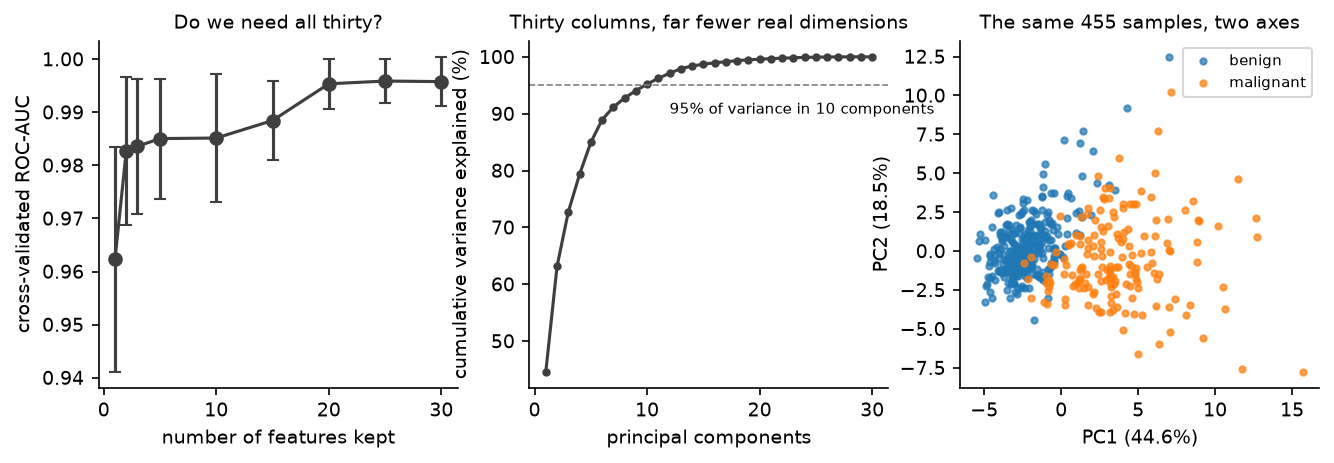

In [46]:
components = pca.transform(standardised)
labels = y_train.values

fig, axs = plt.subplots(1, 3, figsize=(10.5, 3.0))
axs[0].errorbar(feature_curve.index, feature_curve["cv_roc_auc"], yerr=feature_curve["sd"],
                fmt="o-", color=HONEST, capsize=3)
axs[0].set_xlabel("number of features kept")
axs[0].set_ylabel("cross-validated ROC-AUC")
axs[0].set_title("Do we need all thirty?", fontsize=9)

axs[1].plot(range(1, 31), cumulative * 100, "o-", ms=3, color=HONEST)
axs[1].axhline(95, ls="--", c="grey", lw=0.8)
axs[1].text(12, 90, "95% of variance in 10 components", fontsize=7)
axs[1].set_xlabel("principal components")
axs[1].set_ylabel("cumulative variance explained (%)")
axs[1].set_title("Thirty columns, far fewer real dimensions", fontsize=9)

axs[2].scatter(components[labels == 0, 0], components[labels == 0, 1],
               s=9, alpha=0.7, color=BENIGN, label="benign")
axs[2].scatter(components[labels == 1, 0], components[labels == 1, 1],
               s=9, alpha=0.7, color=MALIGNANT, label="malignant")
axs[2].set_xlabel(f"PC1 ({100 * pca.explained_variance_ratio_[0]:.1f}%)")
axs[2].set_ylabel(f"PC2 ({100 * pca.explained_variance_ratio_[1]:.1f}%)")
axs[2].legend(fontsize=7)
axs[2].set_title(f"The same {len(X_train)} samples, two axes", fontsize=9)
fig.savefig("figures/features-and-pca.png")
plt.show()

Ten mixtures carry 95% of what thirty columns contain. That is finding 6, quantified.

And PC1 is interpretable, which is not always true: its largest loadings are `concave_points_mean`,
`concavity_mean`, `concave_points_worst` and `compactness_mean` — the outline-irregularity cluster. **The
dominant axis of variation in this dataset is nuclear shape irregularity.** The data found the biology on its
own, and it agrees with what a cytologist reads down a microscope.

Two honest caveats before reaching for PCA reflexively:

**You lose interpretability at the point of use.** "0.26 × concave points + 0.26 × concavity + …" is not a
quantity anyone can measure on a slide, and you cannot drop the other twenty-five columns, because every
component needs all of them.

**PCA never looks at the labels.** It maximises variance, not separation. If your biggest source of variance
is a batch effect or a staining artefact, PC1 will faithfully capture *that* instead of your biology — which
is exactly what happens with genomics data, and a preview of article 4.

For thirty interpretable features, feature selection usually beats PCA. For 20,000 genes, dimensionality
reduction stops being optional.

---
## What I would put my name on

The result, stated the way a result should be stated.

In [47]:
final_train_acc = model.score(X_train, y_train)
final_test_acc = model.score(X_test, y_test)

print("MODEL")
print("  Logistic regression, L2 regularisation (C=1), all 30 standardised features,")
print("  fitted inside a pipeline that scales using training statistics only.")
print(f"  Trained on {len(X_train)} samples; {len(X_test)} held out.")
print()
print("VALIDATION")
print("  Repeated stratified 5-fold cross-validation (5 x 10) on the training set.")
print("  One held-out test set, evaluated once.")
print()
print("PERFORMANCE")
print(f"  cross-validated accuracy  {repeated_scores.mean():.3f} +/- {repeated_scores.std():.3f}")
print(f"  test accuracy             {final_test_acc:.3f}  (95% CI {acc_lo:.3f}-{acc_hi:.3f})")
print(f"  test recall               {metrics['recall']:.3f}  (95% CI {rec_lo:.3f}-{rec_hi:.3f})")
print(f"  test precision            {metrics['precision']:.3f}")
print(f"  test ROC-AUC              {roc_auc:.3f}")
print(f"  errors                    {fn} false negatives, {fp} false positives in {len(y_test)} samples")
print(f"  training accuracy         {final_train_acc:.3f}  (train-test gap {final_train_acc - final_test_acc:+.3f})")
print(f"  baseline (all benign)     {1 - y_test.mean():.3f}")
print()
print("CONTROLS")
print(f"  blank (predict benign always)   {1 - y_test.mean():.3f} on the test split")
print(f"  replicate (repeated 5x10 CV)    {repeated_scores.mean():.3f} +/- {repeated_scores.std():.3f}")
print(f"  negative control (1,000 label shuffles)")
print(f"      null accuracy               {null_scores.mean():.3f} +/- {null_scores.std():.3f}")
print(f"      highest a shuffle reached   {null_scores.max():.3f}")
print(f"      p-value                     {p_value:.3f}")
print(f"  sham (5,000 noise columns, selection inside each fold)  {honest.mean():.3f}, below baseline")
print()
print("THRESHOLD")
print("  0.5, by default, not by argument. A lower threshold trades false positives for missed")
print("  cancers and should be chosen on validation data against explicit clinical costs.")
print()
print("CONSISTENCY WITH BIOLOGY")
print("  The largest effect sizes and the dominant axis of variation are both nuclear outline")
print("  irregularity, matching diagnostic cytology. Individual coefficients are NOT interpreted,")
print("  because features correlate above 0.99.")
print()
print("LIMITS")
print("  One institution, one era, early-1990s instruments. No patient context, no documented units.")
print("  A teaching dataset. Performance here says nothing about slides from another hospital.")
print("  NOTHING HERE IS FOR CLINICAL USE.")

MODEL
  Logistic regression, L2 regularisation (C=1), all 30 standardised features,
  fitted inside a pipeline that scales using training statistics only.
  Trained on 455 samples; 114 held out.

VALIDATION
  Repeated stratified 5-fold cross-validation (5 x 10) on the training set.
  One held-out test set, evaluated once.

PERFORMANCE
  cross-validated accuracy  0.973 +/- 0.015
  test accuracy             0.965  (95% CI 0.913-0.986)
  test recall               0.929  (95% CI 0.810-0.975)
  test precision            0.975
  test ROC-AUC              0.996
  errors                    3 false negatives, 1 false positives in 114 samples
  training accuracy         0.987  (train-test gap +0.022)
  baseline (all benign)     0.632

CONTROLS
  blank (predict benign always)   0.632 on the test split
  replicate (repeated 5x10 CV)    0.973 +/- 0.015
  negative control (1,000 label shuffles)
      null accuracy               0.597 +/- 0.015
      highest a shuffle reached   0.644
      p-value   

That last block is the one most people skip, and it is the one that makes the rest believable.

---

## The hinge

We now have a model, a defensible estimate of its performance, and a list of the ways it could have been
quietly wrong.

And here is where the series turns. Everything above lives in **one notebook, on one laptop**, for thirty
features and 569 samples that arrived in a single 124 KB file. It runs when I run it, in the order I happen to
run the cells, with library versions I did not write down.

Which raises the questions article 4 is about:

- Could another scientist reproduce this exactly, without sitting next to me?
- What happens when it is 20,000 genes instead of 30 features, across several sequencing runs, with clinical
  metadata someone typed by hand?
- Ten thousand new samples arrive next Tuesday. Does anything built above still work?
- Who notices when the model quietly gets worse?

**Article 4:** the same analysis rebuilt as software. Project structure, version control, functions and
scripts and environments, pipelines that run end to end without a human clicking cells, what breaks at
genomics scale, and what "production" actually means.

The analysis is correct. It is not yet something anyone else can depend on.